# Time Series visualization

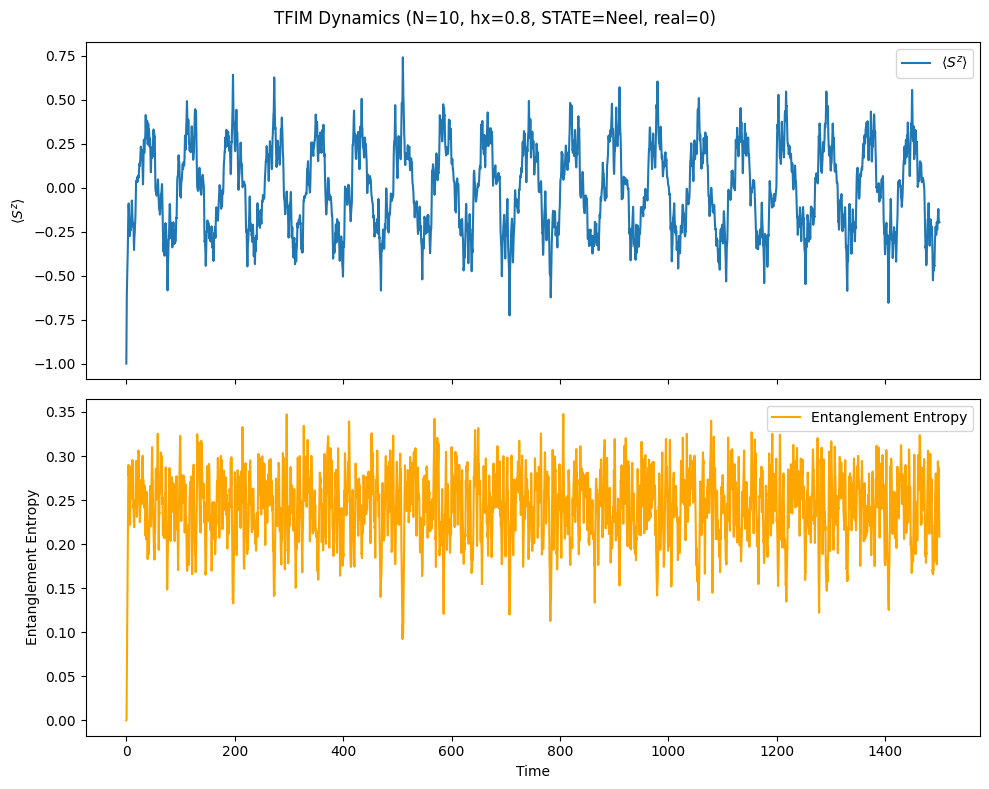

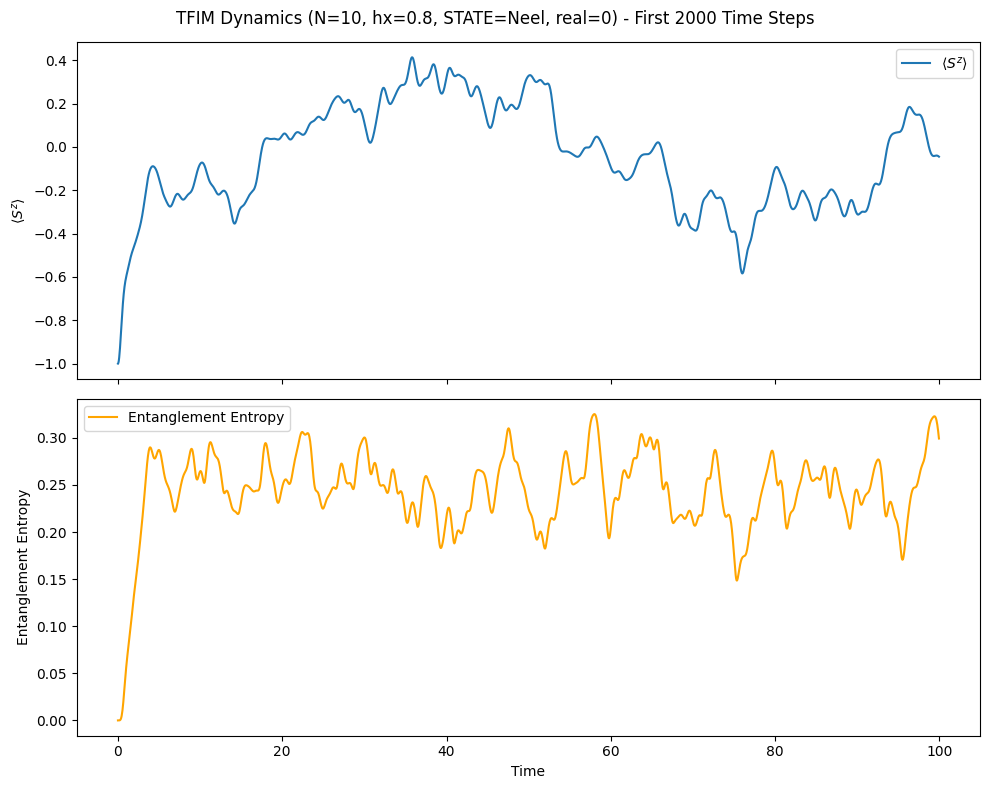

In [2]:
# Plot time series

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# import time series from data folder

SYSTEM = 'TFIM'
N = 10
hx = 0.8
STATE = "Neel" # initial state: "Neel" or "Paramagnet"
BC      = "open"  # 'open' or 'periodic'
if BC == 'periodic':
    SYSTEM += f'_{BC}'
real = 0

# Load data from npy files
sz_dynamics = np.load(f'data/{SYSTEM}_sz_dynamics_N{N}_hx{hx}_{STATE}_{real}.npy')
entropy_dynamics = np.load(f'data/{SYSTEM}_sent_N{N}_hx{hx}_{STATE}_{real}.npy')
tgrid = np.load(f'data/{SYSTEM}_tgrid.npy')

delta_t = tgrid[1] - tgrid[0]

# Plot time series, seperate y-axis for <Sz> and entanglement entropy

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axs[0].plot(tgrid, sz_dynamics, label=r'$\langle S^z \rangle$')
axs[0].set_ylabel(r'$\langle S^z \rangle$')
axs[0].legend()
axs[1].plot(tgrid, entropy_dynamics, label='Entanglement Entropy', color='orange')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Entanglement Entropy')
axs[1].legend()
plt.suptitle(f'{SYSTEM} Dynamics (N={N}, hx={hx}, STATE={STATE}, real={real})')
plt.tight_layout()
plt.show()

t_final = 100
final_idx = int(t_final / delta_t)

# Plot time series at first 100 time steps
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axs[0].plot(tgrid[:final_idx], sz_dynamics[:final_idx], label=r'$\langle S^z \rangle$')
axs[0].set_ylabel(r'$\langle S^z \rangle$')
axs[0].legend()
axs[1].plot(tgrid[:final_idx], entropy_dynamics[:final_idx], label='Entanglement Entropy', color='orange')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Entanglement Entropy')
axs[1].legend()
plt.suptitle(f'{SYSTEM} Dynamics (N={N}, hx={hx}, STATE={STATE}, real={real}) - First {final_idx} Time Steps')
plt.tight_layout()
plt.show()


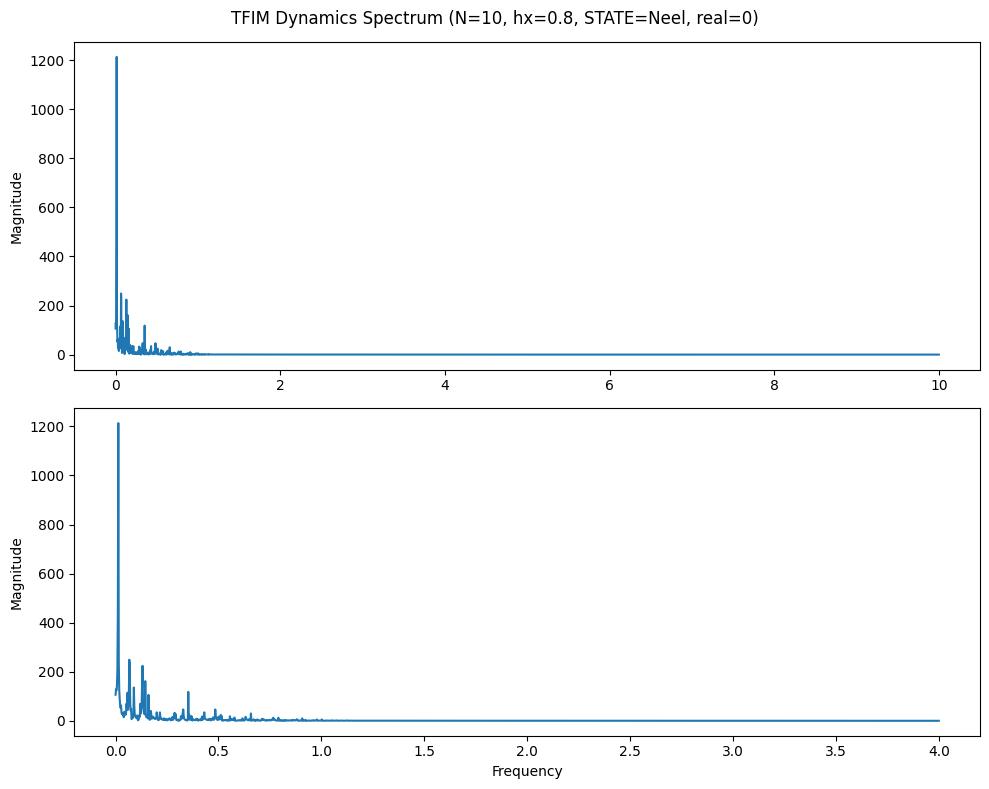

Peak frequencies: [0.00222198 0.01333185 0.0266637  0.03332963 0.04221753 0.05332741
 0.05777136 0.06665926 0.07554716 0.08887901 0.09998889 0.10443284
 0.11554272 0.11998667 0.13109654 0.1444284  0.15109432 0.15998222
 0.1710921  0.18220198 0.19331185 0.19997778 0.20886568 0.21553161
 0.22441951 0.23552939 0.23997334 0.24886124 0.26219309 0.26885902
 0.27774692 0.28663482 0.29107877 0.29996667 0.30441062 0.30885457
 0.31774247 0.32885235 0.34662815 0.35329408 0.35773803 0.36884791
 0.37551383 0.38440173 0.38884568 0.39328963 0.39773359 0.41106544
 0.41550939 0.41995334 0.42439729 0.43106322 0.45106099 0.45994889
 0.46439285 0.4688368  0.47328075 0.48439062 0.49994445 0.51105433
 0.51549828 0.5221642  0.52660815 0.53994001 0.54438396 0.54882791
 0.55549383 0.56438174 0.57104766 0.57771359 0.58215754 0.58882346
 0.59771137 0.60215532 0.60882124 0.61770914 0.631041   0.6488168
 0.6577047  0.66214865 0.67103655 0.67992445 0.6843684  0.68881235
 0.69770026 0.71103211 0.71992001 0.72436396 

In [4]:
# Fourier transform of time series to get frequency spectrum and plot it
from scipy.fft import rfft, rfftfreq
# Compute Fourier transform

# burn in the first 100 time steps to focus on long-term dynamics
burn_in_idx = int(50 / delta_t)

sz_fft = rfft(sz_dynamics[burn_in_idx:])
freqs = rfftfreq(len(tgrid[burn_in_idx:]), delta_t)
zoom_freq = 4
zoom_idx = freqs <= zoom_freq

# Plot frequency spectrum
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(freqs, np.abs(sz_fft))
axs[0].set_ylabel('Magnitude')
axs[1].plot(freqs[zoom_idx], np.abs(sz_fft[zoom_idx]))
axs[1].set_xlabel('Frequency')
axs[1].set_ylabel('Magnitude')
plt.suptitle(f'{SYSTEM} Dynamics Spectrum (N={N}, hx={hx}, STATE={STATE}, real={real})')
plt.tight_layout()
plt.show()

# Find peaks in the frequency spectrum
from scipy.signal import find_peaks
peaks, _ = find_peaks(np.abs(sz_fft), height=0.1)
peak_freqs = freqs[peaks]
print(f'Peak frequencies: {peak_freqs}')

# Number of points in one period of the dominant frequency
dominant_freq = peak_freqs[0]
period = 1 / dominant_freq
points_per_period = int(period / delta_t)
print(f'Dominant frequency: {dominant_freq}, Period: {period}, Points per period: {points_per_period}')

In [9]:
# In cv_results folder, read the csv files and save the data in a pandas dataframe
import os
cv_results_dir = 'cv_results'
cv_results_files = [f for f in os.listdir(cv_results_dir) if f.endswith('.csv')]
# Each file is named as 'TFIM_N{N}_hx{hx}_{STATE}_{real}_volterra.csv, read the parameters from the file name and save them in a list

cv_results_data = []
for file in cv_results_files:
    # note that the file name is 'TFIM_N{N}_hx{hx}_{STATE}_{real}_volterra.csv, split the file name by '_' and extract the parameters
    params = file.split('_')
    print(params)
    N = int(params[1][1:])
    hx = float(params[2][2:])
    STATE = params[3]
    real = int(params[4])
    df = pd.read_csv(os.path.join(cv_results_dir, file))
    df['N'] = N
    df['hx'] = hx
    df['STATE'] = STATE
    df['real'] = real
    print(df)
    # In each file, there are Validation, Best Parameters, Minimum Error, save them in the dataframe
    # in csv, the validation is saved as string of list '[...]', convert it to list of float
    # df['Validation'] = df['Validation'].apply(lambda x: float(x.strip('[]')))
    # df['Best Parameters'] = df['Best Parameters'].apply(lambda x: float(x.strip('[]')))
    # df['Minimum Error'] = df['Minimum Error'].apply(lambda x: float(x.strip('[]')))
    cv_results_data.append(df)

['TFIM', 'N6', 'hx1.0', 'Neel', '0', 'volterra.csv']
         Validation                                    Best Parameters  \
0   [200, 500, 500]            [0.9999932998124965, 1e-07, 1e-06, 0.0]   
1   [500, 500, 500]  [0.9850750445494817, 0.0001105295141126022, 1e...   
2  [1000, 500, 500]  [0.9925943153077376, 1.3503140378698721e-05, 1...   
3  [1500, 500, 500]  [0.9925943153077376, 1.3503140378698721e-05, 1...   
4  [2000, 500, 500]  [0.9963253380592633, 1.6496480740980207e-06, 1...   

   Minimum Error  N   hx STATE  real  
0       0.032752  6  1.0  Neel     0  
1       0.019515  6  1.0  Neel     0  
2       0.006721  6  1.0  Neel     0  
3       0.003101  6  1.0  Neel     0  
4       0.001645  6  1.0  Neel     0  
['TFIM', 'N8', 'hx8.0', 'Neel', '0', 'volterra.csv']
         Validation                                    Best Parameters  \
0   [200, 500, 500]  [0.9850750445494817, 0.06061898993497572, 0.01...   
1   [500, 500, 500]  [0.9850750445494817, 0.06061898993497572, 0.01

In [19]:
# Concatenate all dataframes in the list into a single dataframe
cv_results_df = pd.concat(cv_results_data, ignore_index=True)
# Convert the 'Validation' column from strings to lists of floats
cv_results_df['Validation'] = cv_results_df['Validation'].apply(lambda x: [float(i) for i in x.strip('[]').split(',')])
# Convert the 'Best Parameters' column from strings to lists of floats
cv_results_df['Best Parameters'] = cv_results_df['Best Parameters'].apply(lambda x: [float(i) for i in x.strip('[]').split(',')])
# Convert the 'Minimum Error' column from strings to floats
cv_results_df['Minimum Error'] = cv_results_df['Minimum Error'].apply(lambda x: float(x))
print(cv_results_df)

                Validation                                    Best Parameters  \
0    [200.0, 500.0, 500.0]            [0.9999932998124965, 1e-07, 1e-06, 0.0]   
1    [500.0, 500.0, 500.0]  [0.9850750445494817, 0.0001105295141126022, 1e...   
2   [1000.0, 500.0, 500.0]  [0.9925943153077376, 1.3503140378698721e-05, 1...   
3   [1500.0, 500.0, 500.0]  [0.9925943153077376, 1.3503140378698721e-05, 1...   
4   [2000.0, 500.0, 500.0]  [0.9963253380592633, 1.6496480740980207e-06, 1...   
5    [200.0, 500.0, 500.0]  [0.9850750445494817, 0.06061898993497572, 0.01...   
6    [500.0, 500.0, 500.0]  [0.9850750445494817, 0.06061898993497572, 0.01...   
7   [1000.0, 500.0, 500.0]  [0.9850750445494817, 0.00022275429519995587, 1...   
8   [1500.0, 500.0, 500.0]  [0.9925943153077376, 0.003674661940736688, 1e-...   
9   [2000.0, 500.0, 500.0]  [0.9925943153077376, 3.324597932270945e-06, 1e...   
10   [200.0, 500.0, 500.0]  [0.9850750445494817, 0.03007882518043102, 0.1,...   
11   [500.0, 500.0, 500.0]  

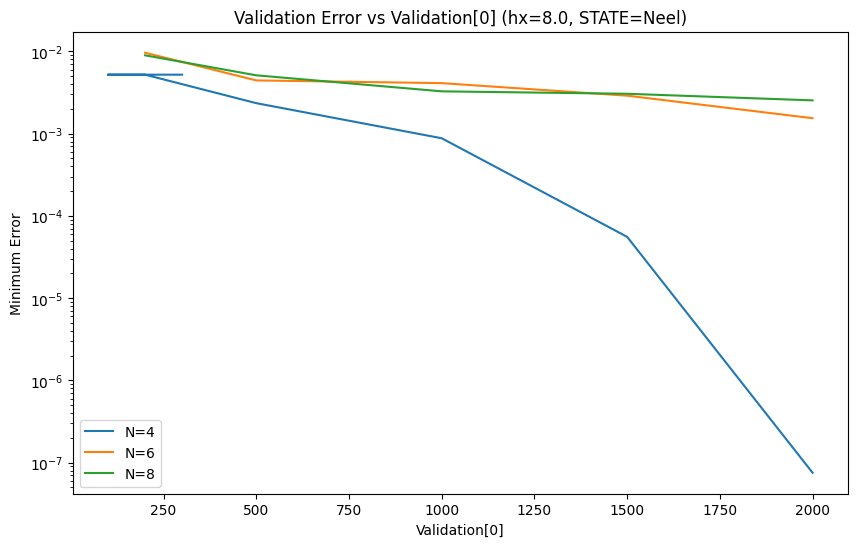

In [29]:
# For given N, hx, and STATE, plot the validation error as a function of Validation[0], Validation is a list, I need the first element of the list, which is Validation[0], and Minimum Error is a single value, plot them as scatter plot
N_list = [4,6,8]
hx = 8.0
STATE = "Neel"
plt.figure(figsize=(10, 6))
for N in N_list:
    filtered_df = cv_results_df[(cv_results_df['N'] == N) & (cv_results_df['hx'] == hx) & (cv_results_df['STATE'] == STATE)]
    plt.semilogy(filtered_df['Validation'].apply(lambda x: x[0]), filtered_df['Minimum Error'], label=f'N={N}')
plt.xlabel('Validation[0]')
plt.ylabel('Minimum Error')
plt.title(f'Validation Error vs Validation[0] (hx={hx}, STATE={STATE})')
plt.legend()
plt.show()

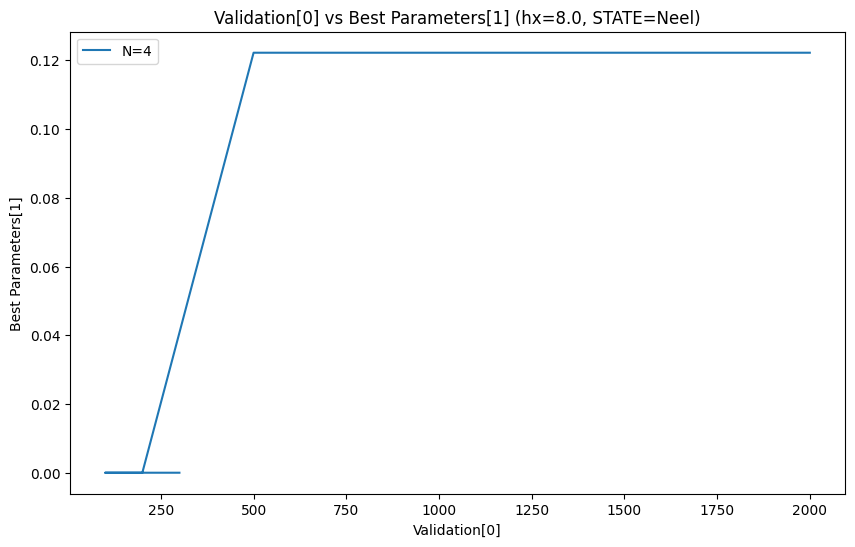

In [31]:
# For given N, hx, and STATE, plot the Validation[0] vs Best Parameters[0], where Validation is a list, I need the first element of the list, which is Validation[0], and Best Parameters is a list, I need the first element of the list, which is Best Parameters[0], plot them as scatter plot
N_list = [4]
hx = 8.0
STATE = "Neel"
plt.figure(figsize=(10, 6))
for N in N_list:
    filtered_df = cv_results_df[(cv_results_df['N'] == N) & (cv_results_df['hx'] == hx) & (cv_results_df['STATE'] == STATE)]
    plt.plot(filtered_df['Validation'].apply(lambda x: x[0]), filtered_df['Best Parameters'].apply(lambda x: x[1]), label=f'N={N}')
plt.xlabel('Validation[0]')
plt.ylabel('Best Parameters[1]')
plt.title(f'Validation[0] vs Best Parameters[1] (hx={hx}, STATE={STATE})')
plt.legend()
plt.show()

In [9]:
from utils.normalisation import normalise_arrays

SYSTEM = 'TFIM'
N = 4
hx = 8.0
STATE = "Neel" # initial state: "Neel" or "Paramagnet"
real = 0
dynamics_type = 'sz_all' # 'sz_dynamics', 'sz_all', 'szsz_all'

# Load data from npy files
data_rawraw = np.load(f'data/{SYSTEM}_{dynamics_type}_N{N}_hx{hx}_{STATE}_{real}.npy')
if data_rawraw.ndim == 1:
    data_raw = np.expand_dims(data_rawraw, axis=1)
else:
    data_raw = data_rawraw.T
print(f"Raw data: {data_raw}")
print(f"Data shape: {data_raw.shape}")

tgrid_raw = np.load(f'data/{SYSTEM}_tgrid.npy')

delta_t = tgrid_raw[1] - tgrid_raw[0]

# Define training and washout size
t_train = 200
ntrain = int(t_train / delta_t)
t_wash = 50
wash = int(t_wash / delta_t)
data = data_raw[wash:] # Ensure data is long enough for training + washout
tgrid = tgrid_raw[wash:]
washout = 0

# Construct training input and teacher, testing input and teacher
training_input_orig = data[0:ntrain-1] 
training_teacher_orig = data[1:ntrain]

# Normalise training arrays if necessary
normalisation_output = normalise_arrays([training_input_orig, training_teacher_orig], norm_type=None)
print(f"Normalisation output: {normalisation_output}")

training_input, training_teacher = normalisation_output[0]
print(f"Training input shape: {training_input.shape}")
print(f"Training teacher shape: {training_teacher.shape}")

print(f"Training input: {training_input}")

Raw data: [[ 1.         -1.          1.         -1.        ]
 [ 0.69695661 -0.6976261   0.6976261  -0.69695661]
 [-0.02593412  0.01952792 -0.01952792  0.02593412]
 ...
 [-0.67931074  0.53672091 -0.53672091  0.67931074]
 [-0.76744666  0.6314007  -0.6314007   0.76744666]
 [-0.41118025  0.36953916 -0.36953916  0.41118025]]
Data shape: (10001, 4)
Normalisation output: ([array([[ 0.23390095, -0.23677635,  0.23677635, -0.23390095],
       [ 0.52612919, -0.40337578,  0.40337578, -0.52612919],
       [ 0.51584654, -0.34550552,  0.34550552, -0.51584654],
       ...,
       [-0.24072099,  0.13546015, -0.13546015,  0.24072099],
       [-0.60700002,  0.39205056, -0.39205056,  0.60700002],
       [-0.57016162,  0.3773065 , -0.3773065 ,  0.57016162]],
      shape=(3999, 4)), array([[ 0.52612919, -0.40337578,  0.40337578, -0.52612919],
       [ 0.51584654, -0.34550552,  0.34550552, -0.51584654],
       [ 0.20083016, -0.09298886,  0.09298886, -0.20083016],
       ...,
       [-0.60700002,  0.39205056,